# Parsing Eyelink `.asc` File

This notebook demonstrates how to load and parse an EyeLink `.asc` file, extract sample data (including timestamps, gaze positions, pupil sizes), and reconstruct the stimulus timeline (when the blue LED is active) using the `BUTTON` events.

In [1]:
import sys
import os
sys.path.append(os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from parse_asc import parse_eyelink_asc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [2]:
file_path = "../../../data/260611.asc"
df = parse_eyelink_asc(file_path)
df

Reading Eyelink ASC file: ../../../data/260611.asc


,timestamp,elasped_ms,elasped_sec,blue_active,gaze_x,gaze_y,pupil_size
0,866527,0,0.000,0,946.9,520.2,11334.0
1,866528,1,0.001,0,947.0,521.2,11337.0
2,866529,2,0.002,0,947.1,521.2,11337.0
3,866530,3,0.003,0,947.1,520.7,11336.0
4,866531,4,0.004,0,947.1,520.3,11335.0
...,...,...,...,...,...,...,...
27507,894034,27507,27.507,0,972.3,543.4,11276.0
27508,894035,27508,27.508,0,972.6,542.8,11274.0
27509,894036,27509,27.509,0,972.4,537.6,11265.0
27510,894037,27510,27.510,0,972.2,532.6,11259.0


In [3]:
# Print summary statistics
print("Shape of DataFrame:", df.shape)
print(f"Recording duration: {df['elasped_sec'].max():.2f} seconds")
print(f"Number of samples: {len(df)}")
print(f"Blue stimulus active time: {(df['blue_active'] == 1).sum()} ms")
print(f"Mean Pupil Size during baseline (before stimulus): {df[df['elasped_ms'] < 1694]['pupil_size'].mean():.2f}")
print(f"Mean Pupil Size during stimulus phase: {df[(df['timestamp'] >= 868221) & (df['timestamp'] <= 872721)]['pupil_size'].mean():.2f}")

Shape of DataFrame: (27512, 7)
Recording duration: 27.51 seconds
Number of samples: 27512
Blue stimulus active time: 2500 ms
Mean Pupil Size during baseline (before stimulus): 11387.08
Mean Pupil Size during stimulus phase: 7669.17


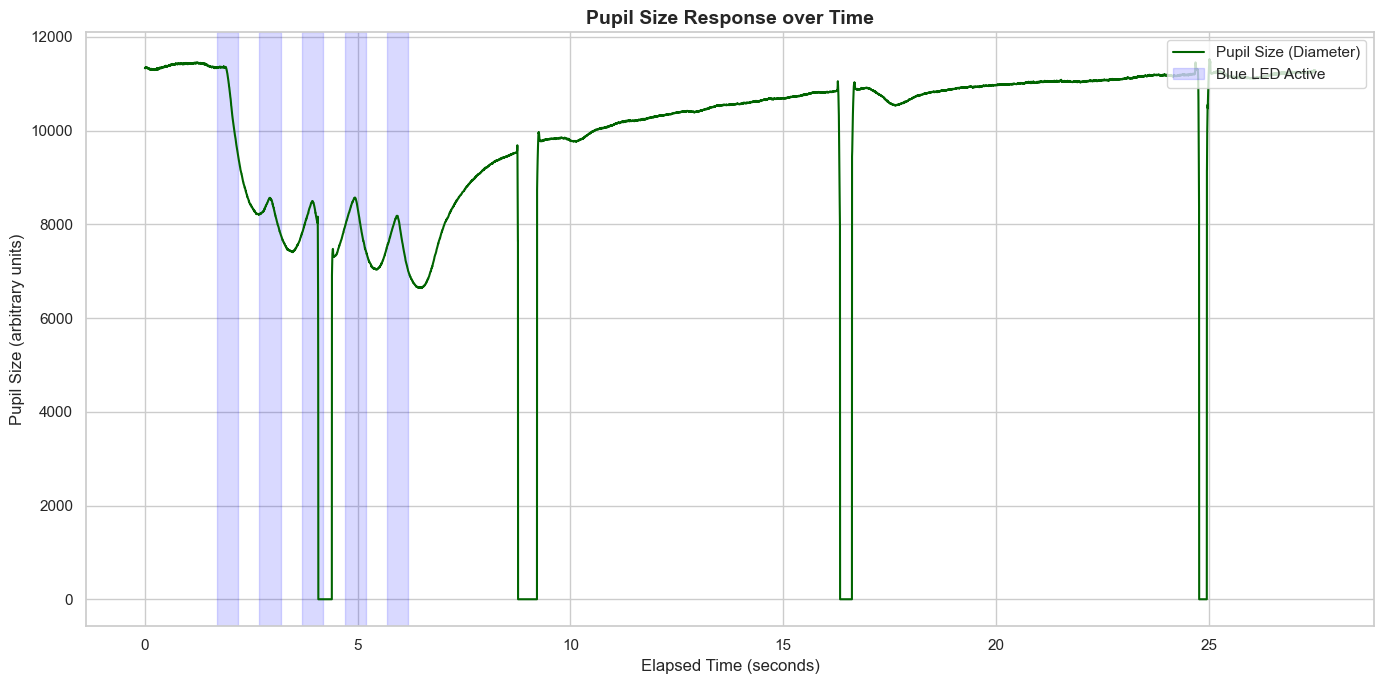

In [4]:
# Plot Pupil Size over Time with Blue Active regions shaded in blue
plt.figure(figsize=(14, 7))
plt.plot(df['elasped_sec'], df['pupil_size'], label="Pupil Size (Diameter)", color="darkgreen", linewidth=1.5)

# Highlight regions where blue LED was active
transitions = df['blue_active'].diff().fillna(0)
starts = df.loc[transitions == 1, 'elasped_sec'].values
ends = df.loc[transitions == -1, 'elasped_sec'].values

# If ends is shorter, append the last timestamp
if len(starts) > len(ends):
    ends = np.append(ends, df['elasped_sec'].max())

for start, end in zip(starts, ends):
    plt.axvspan(start, end, color="blue", alpha=0.15, label="Blue LED Active" if start == starts[0] else "")

plt.title("Pupil Size Response over Time", fontsize=14, fontweight="bold")
plt.xlabel("Elapsed Time (seconds)", fontsize=12)
plt.ylabel("Pupil Size (arbitrary units)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [5]:
df.to_csv(f'../../../out/{os.path.basename(file_path)[:-4]}.csv', index=False)
df.to_excel(f'../../../out/{os.path.basename(file_path)[:-4]}.xlsx', index=False)